## EDA del dataset Framingham

Objetivo

El objetivo de este análisis exploratorio es estudiar qué características de salud y estilo de vida están relacionadas con la aparición de enfermedad coronaria a 10 años (`TenYearCHD`).

Tenemos variables demográficas, hábitos de tabaco, antecedentes médicos y medidas clínicas como colesterol, presión arterial, IMC, frecuencia cardíaca y glucosa.

## Preguntas

- ¿Qué proporción de pacientes desarrolla enfermedad coronaria a 10 años?
- ¿Hay diferencias relevantes según edad, sexo o tabaquismo?
- ¿Qué variables clínicas parecen asociarse más con `TenYearCHD`?
- ¿Existen valores nulos, atípicos o inconsistencias que debamos tratar?


## Hipótesis iniciales

Antes de comenzar el análisis, considero que las variables más relacionadas con el riesgo de enfermedad coronaria a 10 años serán la edad, la presión arterial, el colesterol, la diabetes y la glucosa.

Mi hipótesis es que los pacientes de mayor edad, con presión arterial más alta, colesterol elevado, diabetes o glucosa alta tendrán mayor proporción de `TenYearCHD = 1`.

También espero que variables de estilo de vida como el tabaquismo puedan estar relacionadas con mayor riesgo, aunque puede que su efecto no sea tan claro al analizarlo de forma aislada.

Por último, creo que variables como la frecuencia cardíaca o el nivel educativo podrían tener una relación menos directa con la variable objetivo.


In [40]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="Set2")

df = pd.read_csv("data/framingham.csv", na_values="NA")

df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [41]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"Duplicados: {df.duplicated().sum()}")

display(df.dtypes.to_frame("tipo_dato"))

resumen_nulos = (
    df.isna()
    .sum()
    .to_frame("nulos")
    .assign(pct_nulos=lambda x: round(x["nulos"] / len(df) * 100, 2))
    .sort_values("pct_nulos", ascending=False)
)

display(resumen_nulos)


Filas: 4240
Columnas: 16
Duplicados: 0


,tipo_dato
male,int64
age,int64
education,float64
currentSmoker,int64
cigsPerDay,float64
BPMeds,float64
prevalentStroke,int64
prevalentHyp,int64
diabetes,int64
totChol,float64


,nulos,pct_nulos
glucose,388,9.15
education,105,2.48
BPMeds,53,1.25
totChol,50,1.18
cigsPerDay,29,0.68
BMI,19,0.45
heartRate,1,0.02
male,0,0.00
age,0,0.00
currentSmoker,0,0.00


## Primera inspección del dataset

El dataset contiene 4240 registros y 16 variables. No hay filas duplicadas.

La mayoría de variables están completas, aunque existen valores nulos en algunas columnas clínicas y sociodemográficas. La variable con más valores ausentes es `glucose`, con algo más del 9% de registros sin información. El resto de columnas con nulos presentan porcentajes bajos.

De momento no voy a eliminar ni imputar valores ausentes. Primero voy a analizar la distribución de la variable objetivo y de las principales variables explicativas y luego veo que tratamiento usar.

,conteo,porcentaje
TenYearCHD,,
0,3596,84.81
1,644,15.19


/var/folders/2q/hp4lnzhj29g5vjty0v59zgmh0000gn/T/ipykernel_38137/3622598928.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No desarrolla CHD", "Desarrolla CHD"])


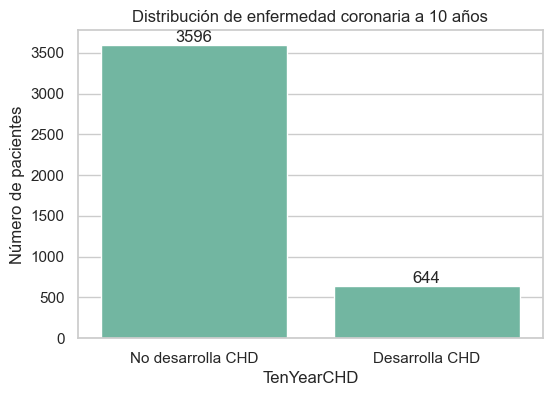

In [42]:
conteo_chd = df["TenYearCHD"].value_counts().sort_index()
porcentaje_chd = df["TenYearCHD"].value_counts(normalize=True).sort_index() * 100

resumen_chd = pd.DataFrame({
    "conteo": conteo_chd,
    "porcentaje": porcentaje_chd.round(2)
})

display(resumen_chd)

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="TenYearCHD")

ax.set_title("Distribución de enfermedad coronaria a 10 años")
ax.set_xlabel("TenYearCHD")
ax.set_ylabel("Número de pacientes")
ax.set_xticklabels(["No desarrolla CHD", "Desarrolla CHD"])

for container in ax.containers:
    ax.bar_label(container)

plt.show()

## Distribución de la variable objetivo

La variable objetivo `TenYearCHD` indica si el paciente desarrolló enfermedad coronaria en un periodo de 10 años.

Veo que claramente está desbalanceada: aproximadamente el 85% de los pacientes no desarrolló enfermedad coronaria, mientras que mas o menos el 15% sí la desarrolló.

In [43]:
variables_numericas = [
    "age", "cigsPerDay", "totChol", "sysBP", "diaBP",
    "BMI", "heartRate", "glucose"
]

df[variables_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
age,4240.0,49.580189,8.572942,32.00,42.00,49.0,56.00,70.0
cigsPerDay,4211.0,9.005937,11.922462,0.00,0.00,0.0,20.00,70.0
totChol,4190.0,236.699523,44.591284,107.00,206.00,234.0,263.00,696.0
sysBP,4240.0,132.354599,22.033300,83.50,117.00,128.0,144.00,295.0
diaBP,4240.0,82.897759,11.910394,48.00,75.00,82.0,90.00,142.5
BMI,4221.0,25.800801,4.079840,15.54,23.07,25.4,28.04,56.8
heartRate,4239.0,75.878981,12.025348,44.00,68.00,75.0,83.00,143.0
glucose,3852.0,81.963655,23.954335,40.00,71.00,78.0,87.00,394.0


## Resumen estadístico de variables numéricas

La edad de los pacientes se sitúa entre 32 y 70 años, con una media cerca de los 50 años. Por lo tanto la muestra esta formada principalmente por adultos de mediana edad y personas mayores.

En cuanto al consumo de tabaco, la mediana de `cigsPerDay` es 0, ya que mas de la mitad no fuma. Pero el máximo alcanza 70 cigarrillos diarios, existiendo fumadores con consumos muy elevados.

Las variables clínicas muestran rangos amplios. El colesterol total (`totChol`) tiene una media aproximada de 237, pero alcanza valores máximos muy altos, como 696. La presión arterial sistólica (`sysBP`) también presenta valores extremos, llegando hasta 295.

El IMC medio es de aproximadamente 25.8, situado en el rango de sobrepeso. También aparecen valores altos de IMC, con un máximo superior a 56.

La glucosa tiene una mediana de 78, pero presenta valores máximos muy elevados, hasta 394. Esto puede indicar pacientes con alteraciones importantes de glucosa o posibles valores extremos que luego voy a revisar.

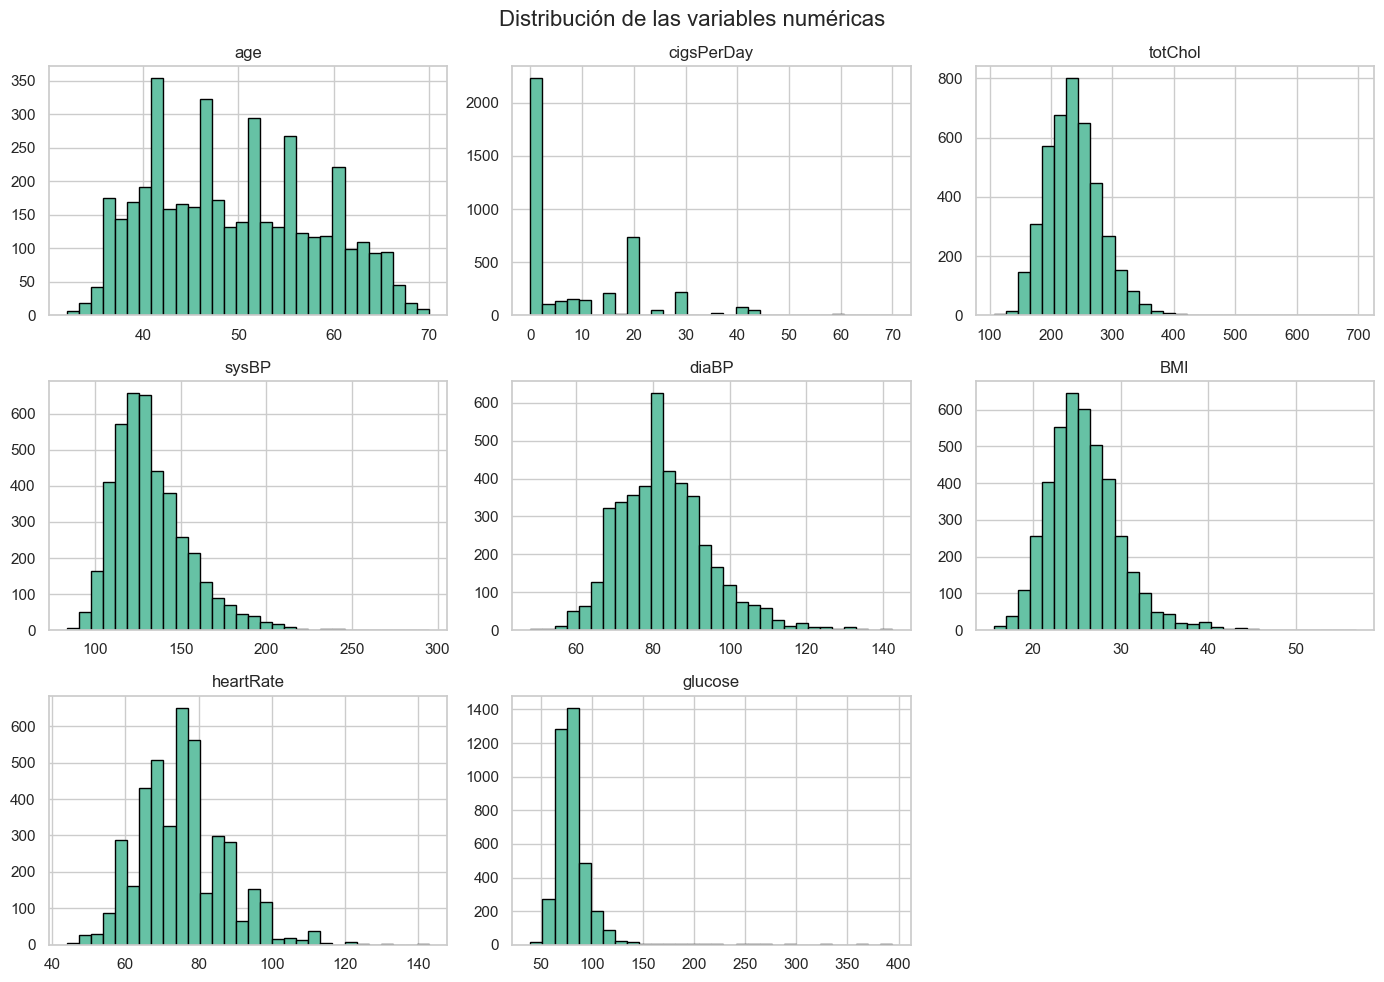

In [44]:
df[variables_numericas].hist(
    figsize=(14, 10),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Distribución de las variables numéricas", fontsize=16)
plt.tight_layout()
plt.show()


## Distribución de las variables numéricas

Las variables numéricas muestran comportamientos distintos.

La edad presenta una distribución repartida entre adultos de mediana edad y mayores, sin valores extremos a simple vista.

`cigsPerDay` tiene una concentración muy alta en 0, debido a la presencia de muchos pacientes no fumadores. Por eso, hay que analizar el consumo de cigarrillos separando únicamente a los fumadores actuales.

Las variables clínicas como `totChol`, `sysBP`, `BMI` y `glucose` presentan asimetría hacia la derecha, indicando que la mayoría de pacientes se concentra en valores moderados, aunque existen registros con valores muy elevados.

Estos valores extremos no los voy a eliminar automáticamente, ya que pueden representar a pacientes con condiciones médicas relevantes. Después voy a revisar con boxplots para detectar posibles outliers.

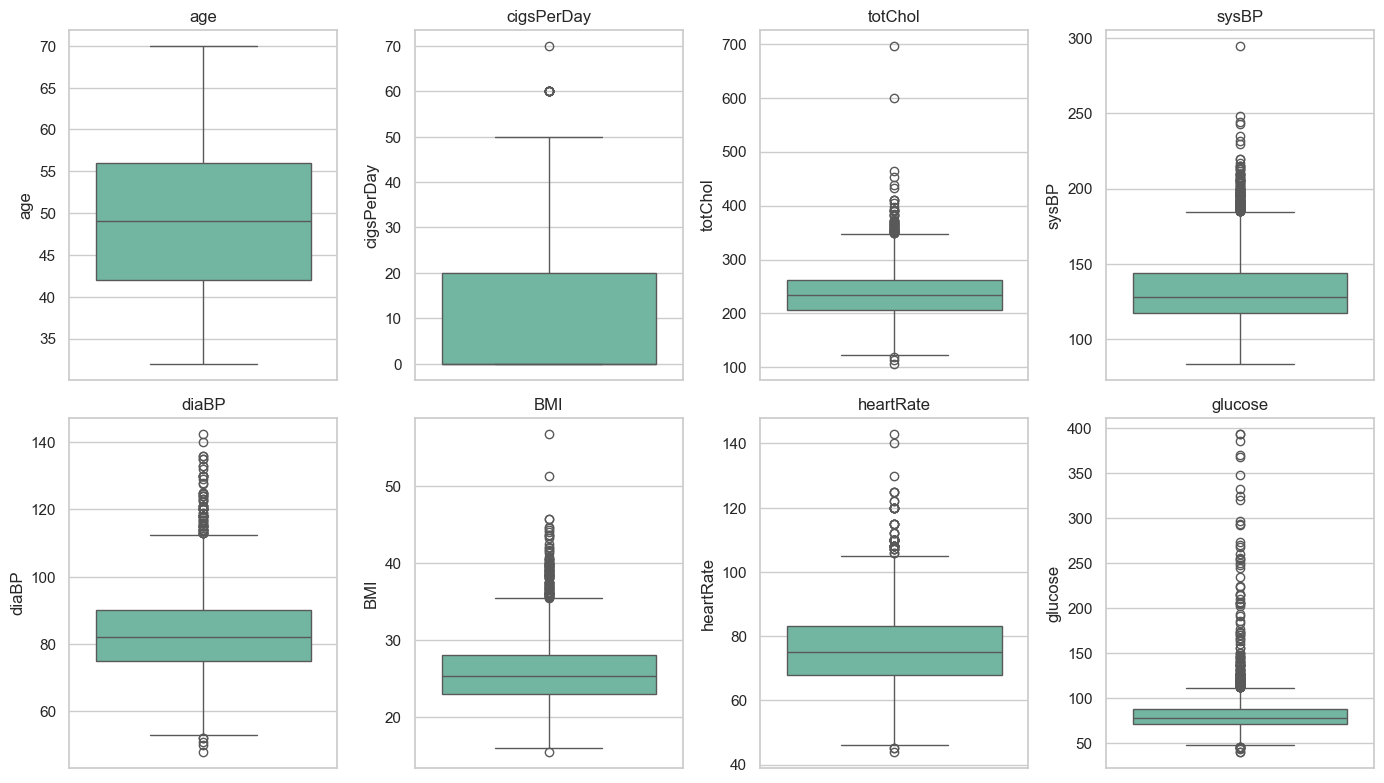

In [45]:
plt.figure(figsize=(14, 8))

for i, col in enumerate(variables_numericas, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

## Valores extremos y outliers "Ayuda de la IA para crear el mapa"

Para ver con más claridad los valores extremos he utilizado gráficos boxplot.

En la variable `age` no se observan outliers claros. Pero en el resto de variables numéricas sí aparecen valores atípicos, especialmente en variables médicas y clínicas como colesterol, presión arterial, IMC y glucosa.

De momento no elimino estos valores, ya que pueden pertenecer a pacientes con problemas de salud relevantes.

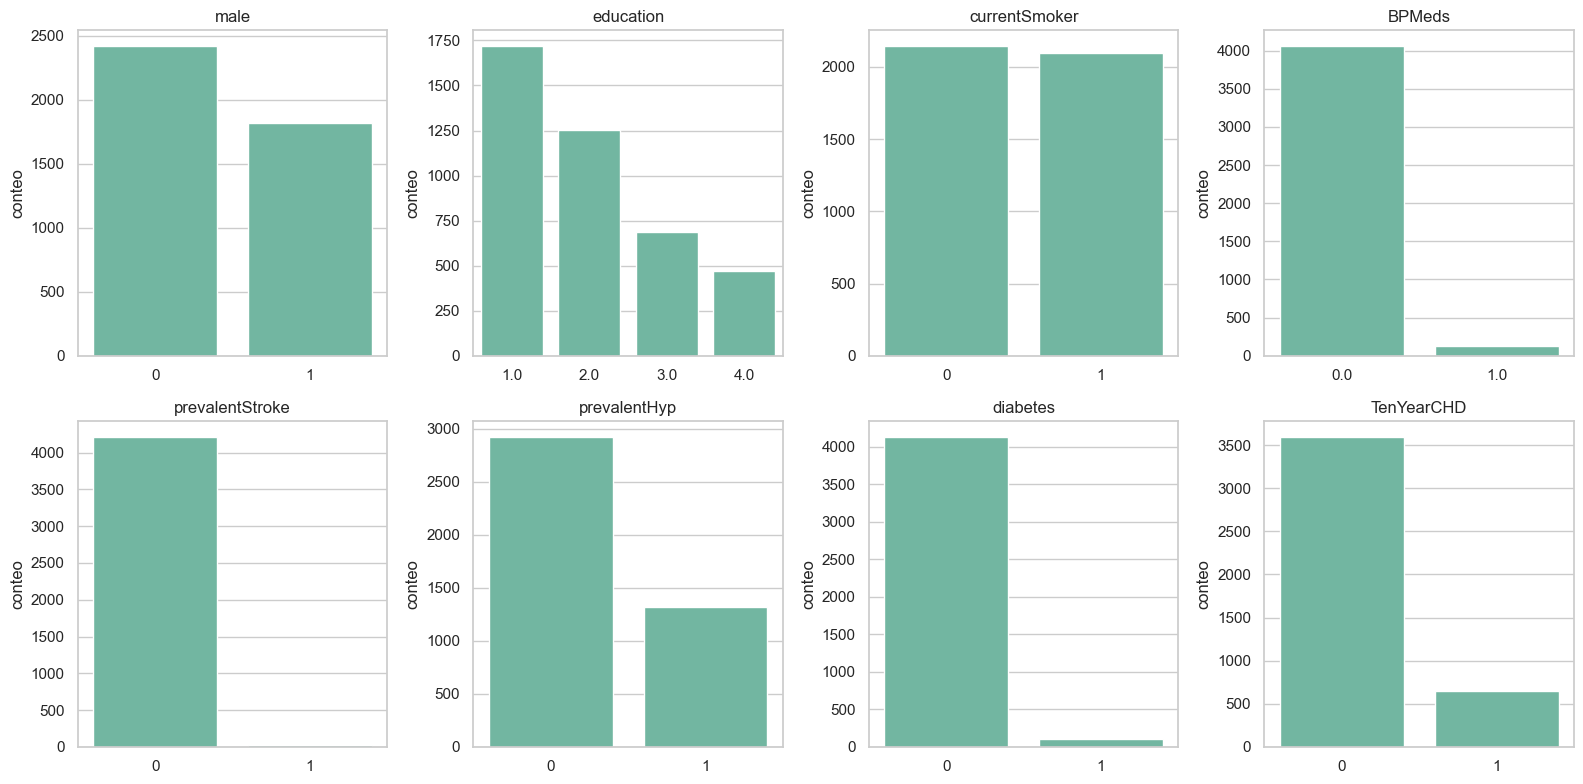

In [46]:
variables_categoricas = [
    "male", "education", "currentSmoker", "BPMeds",
    "prevalentStroke", "prevalentHyp", "diabetes", "TenYearCHD"
]

plt.figure(figsize=(16, 8))

for i, col in enumerate(variables_categoricas, 1):
    plt.subplot(2, 4, i)
    sns.countplot(data=df, x=col)
    plt.title(col)
    plt.xlabel("")
    plt.ylabel("conteo")

plt.tight_layout()
plt.show()

## Distribución de variables categóricas "Ayuda de la IA para crear los graficos"

En las variables categóricas puedo ver varios desbalances.

La variable `male` muestra que hay más registros de mujeres que de hombres. Pero si vemos `currentSmoker` la vemos bastante equilibrada, con una proporción muy parecida entre fumadores y no fumadores actuales.

La mayoría de pacientes no toma medicación para la presión arterial (`BPMeds`), no ha tenido ictus previo (`prevalentStroke`) y no tiene diabetes. Estas variables tienen pocos casos positivos.

La hipertensión prevalente (`prevalentHyp`) sí aparece en una parte importante de la muestra, alrededor de un tercio de los pacientes.

En `education` predominan los niveles 1 y 2, aunque también hay algunos valores ausentes.

Por último, `TenYearCHD` vuelve a mostrar el desbalance ya observado: la mayoría de pacientes no desarrolla enfermedad coronaria a 10 años.


## Análisis bivariado

En esta parte analizo la relación entre la variable objetivo `TenYearCHD` y el resto de variables del dataset.

Primero comparo las variables numéricas según si el paciente desarrolla o no enfermedad coronaria a los 10 años. Después analizo algunas variables categóricas o binarias, como sexo, tabaquismo, hipertensión o diabetes.

Este análisis permite ver qué características parecen asociarse con una mayor proporción de enfermedad coronaria.

In [47]:
df.groupby("TenYearCHD")[variables_numericas].mean().T

TenYearCHD,0,1
age,48.762514,54.145963
cigsPerDay,8.713925,10.629283
totChol,235.147398,245.388976
sysBP,130.337319,143.618789
diaBP,82.166435,86.981366
BMI,25.671659,26.531451
heartRate,75.762514,76.530327
glucose,80.679251,89.008418


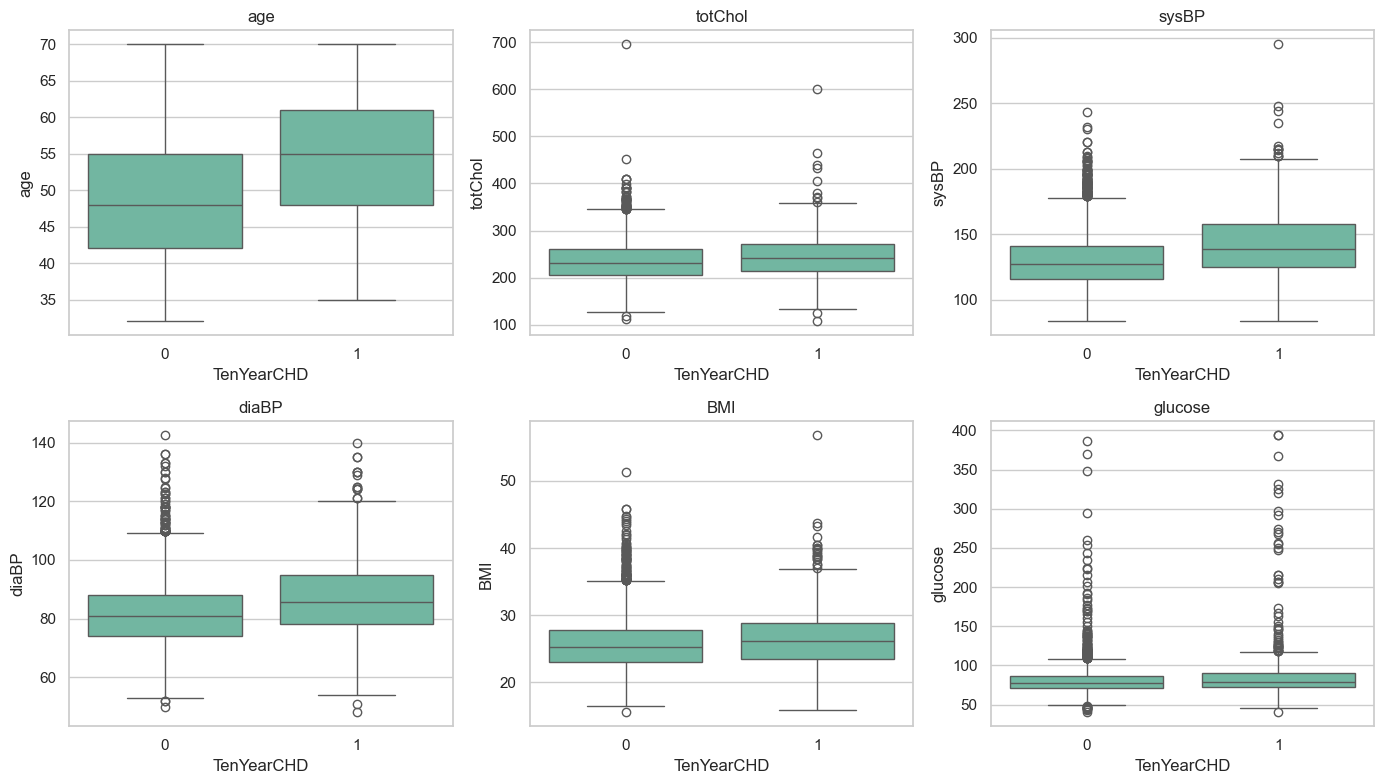

In [48]:
variables_comparar = ["age", "totChol", "sysBP", "diaBP", "BMI", "glucose"]

plt.figure(figsize=(14, 8))

for i, col in enumerate(variables_comparar, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x="TenYearCHD", y=col)
    plt.title(col)
    plt.xlabel("TenYearCHD")
    plt.ylabel(col)

plt.tight_layout()
plt.show()


## Variables numéricas según enfermedad coronaria

Al comparar las variables numéricas mediante `TenYearCHD`, puedo ver diferencias entre los pacientes que desarrollan enfermedad coronaria y los que no.

Los pacientes con `TenYearCHD = 1` presentan una edad media mayor. También tienen valores medios más altos de presión arterial sistólica y diastólica, colesterol total y glucosa.

En los boxplots se aprecia que las distribuciones de ambos grupos se solapan bastante, por lo que ninguna variable por sí sola separa de manera clara a los pacientes con y sin enfermedad coronaria. Variables como `age`, `sysBP` y `glucose` parecen mostrar diferencias relevantes.

Esto sugiere que el riesgo de enfermedad coronaria podría estar relacionado con una combinación de factores clínicos y no con una única variable aislada.

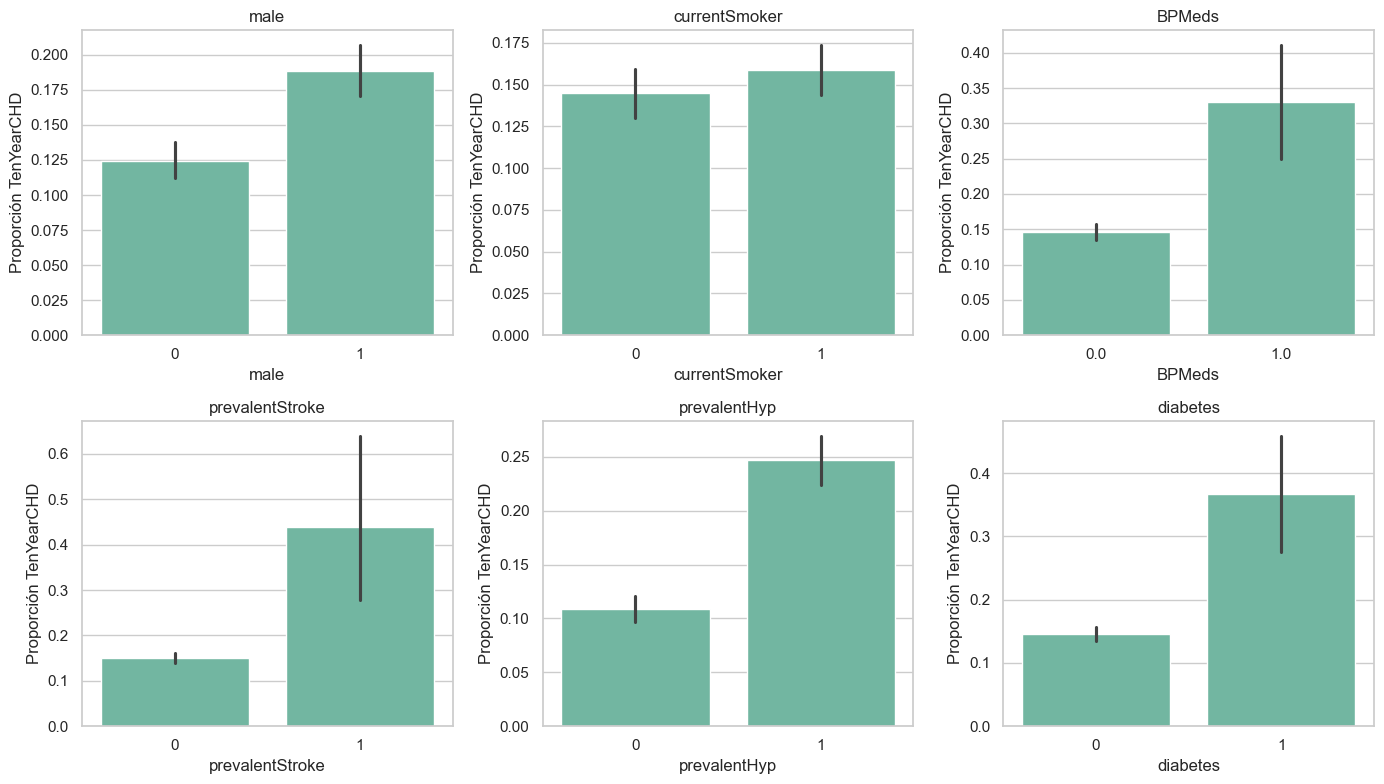

In [49]:
variables_riesgo = ["male", "currentSmoker", "BPMeds", "prevalentStroke", "prevalentHyp", "diabetes"]

plt.figure(figsize=(14, 8))

for i, col in enumerate(variables_riesgo, 1):
    plt.subplot(2, 3, i)
    sns.barplot(data=df, x=col, y="TenYearCHD")
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Proporción TenYearCHD")

plt.tight_layout()
plt.show()

## Variables categóricas según enfermedad coronaria "Ayuda de la IA para crear los graficos"

Al comparar las variables categóricas con `TenYearCHD`, puedo ver diferencias claras en algunos grupos.

Los hombres presentan más casos de enfermedad coronaria que las mujeres. En cambio, la diferencia entre fumadores y no fumadores actuales es más pequeña de lo que esperaba al hacer este análisis simple.

Las variables relacionadas con antecedentes o condiciones médicas tienen diferencias más marcadas. Los pacientes que toman medicación para la presión arterial (`BPMeds`), los que tienen hipertensión prevalente (`prevalentHyp`), diabetes o antecedentes de ictus presentan una proporción más alta de enfermedad coronaria a 10 años.

Estos resultados tienen sentido médico, ya que hipertensión, diabetes y antecedentes cardiovasculares suelen estar relacionados con un mayor riesgo cardiovascular.

## Análisis multivariante

En esta parte analizo la relación entre varias variables numéricas del dataset mediante una matriz de correlaciones.

Este análisis permite observar qué variables se relacionan entre sí y cuáles tienen una relación más directa con la variable objetivo `TenYearCHD`.

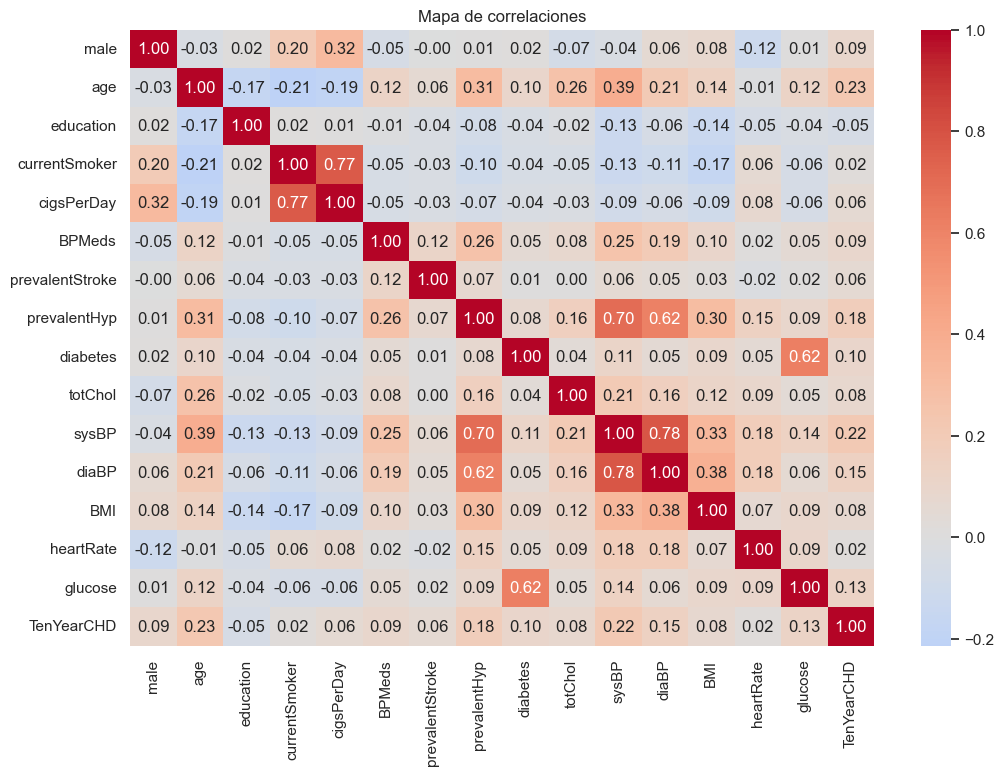

In [50]:
plt.figure(figsize=(12, 8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Mapa de correlaciones")
plt.show()


## Correlaciones entre variables

He usado un mapa de correlaciones para poder ver relaciones lineales entre las variables numéricas del dataset.

Las dos correlaciones más claras que veo son entre la presión arterial sistólica (`sysBP`) y la presión arterial diastólica (`diaBP`), algo esperable porque ambas miden aspectos relacionados de la presión arterial y entre `currentSmoker` y `cigsPerDay` ya que hay correlación entre los fumadores actuales y los que más cigarrillos fuman al día.

También veo una relación positiva entre `prevalentHyp` y las variables de presión arterial, especialmente con `sysBP`.

Respecto a `TenYearCHD`, las correlaciones más altas son con `age`, `sysBP`, `prevalentHyp`, `diaBP` y `glucose`. Aun así, las correlaciones no son muy elevadas, por lo que parece que el riesgo de enfermedad coronaria depende de varios factores combinados y no de una única variable

In [51]:
df.isna().sum().sort_values(ascending=False)

glucose            388
education          105
BPMeds              53
totChol             50
cigsPerDay          29
BMI                 19
heartRate            1
male                 0
age                  0
currentSmoker        0
prevalentStroke      0
prevalentHyp         0
diabetes             0
sysBP                0
diaBP                0
TenYearCHD           0
dtype: int64

## Tratamiento de valores nulos

En este análisis no elimino ni imputo los valores nulos, ya que el objetivo principal considero que es hacer una exploración del dataset.

La variable con más valores ausentes es `glucose`, con algo más del 9% de registros sin información. El resto de variables con nulos presentan porcentajes bajos.

Si en este proyecto me pongo a crear un modelo predictivo, sería necesario tratar estos valores antes de entrenar. Una opción sencilla sería imputar las variables numéricas con la mediana y las variables categóricas con la moda.

## Conclusiones finales

Después de realizar el análisis exploratorio, las hipótesis iniciales se cumplen en gran parte.

Los pacientes que desarrollan enfermedad coronaria a los 10 años presentan, de media, mayor edad, presión arterial sistólica y diastólica más alta, mayor colesterol total y valores más altos de glucosa.

También he visto una mayor proporción de enfermedad coronaria en pacientes con hipertensión, diabetes, medicación para la presión arterial o antecedentes de ictus. Estas variables podrían estar asociadas con un mayor riesgo cardiovascular.

El tabaquismo aparece bastante equilibrado entre fumadores y no fumadores actuales, y su relación con `TenYearCHD` no es tan clara en este análisis simple como esperaba, pensaba que iba a tener mayor importancia y peso.

Las correlaciones con la variable objetivo no son muy elevadas, por lo que no parece que una única variable explique por sí sola el riesgo de enfermedad coronaria. Diría icluso que el riesgo parece depender de una combinación de factores demográficos, clínicos y de estilo de vida.

Como limitaciones del análisis, hay que tener en cuenta la presencia de valores nulos, valores extremos y el desbalance de la variable objetivo, ya que solo alrededor del 15% de los pacientes desarrolla enfermedad coronaria a 10 años.